<a href="https://colab.research.google.com/github/Azyur-i/CS182-03/blob/main/FA7/CO1FA7.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# FA7: Building a Time Series and Forecasting Model
By: Heughric Fernando and Jan Christian Diesta (Group 7)

# Loading Dataset and Preparation

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from statsmodels.tsa.stattools import adfuller
from statsmodels.tsa.statespace.sarimax import SARIMAX
from sklearn.metrics import mean_absolute_percentage_error, mean_squared_error

sns.set(style="whitegrid")

df=pd.read_csv("AirPassengers.csv")

df.columns=[c.strip() for c in df.columns]
df=df.rename(columns={"#Passengers":"Passengers"})

df["Month"]=pd.to_datetime(df["Month"])
df=df.set_index("Month").sort_index()

df=df.asfreq("MS")

print("Dataset shape: ", df.shape)
print(df.head())
print("\nMissing Value: \n", df.isna().sum())

df["LogPassengers"]=np.log(df["Passengers"])
print("\n")
print(df[["Passengers","LogPassengers"]].head())


Dataset shape:  (144, 1)
            Passengers
Month                 
1949-01-01         112
1949-02-01         118
1949-03-01         132
1949-04-01         129
1949-05-01         121

Missing Value: 
 Passengers    0
dtype: int64


            Passengers  LogPassengers
Month                                
1949-01-01         112       4.718499
1949-02-01         118       4.770685
1949-03-01         132       4.882802
1949-04-01         129       4.859812
1949-05-01         121       4.795791


- We import the core libraries needed for Time Series & Forecasting Model
- We load the AirPassengers dataset.
- Convert the Month column into a datetime format.
- Set Month as the index to form a time series.
- Add a timely frequency to keep the time line consistent.

# Visualizing the time series

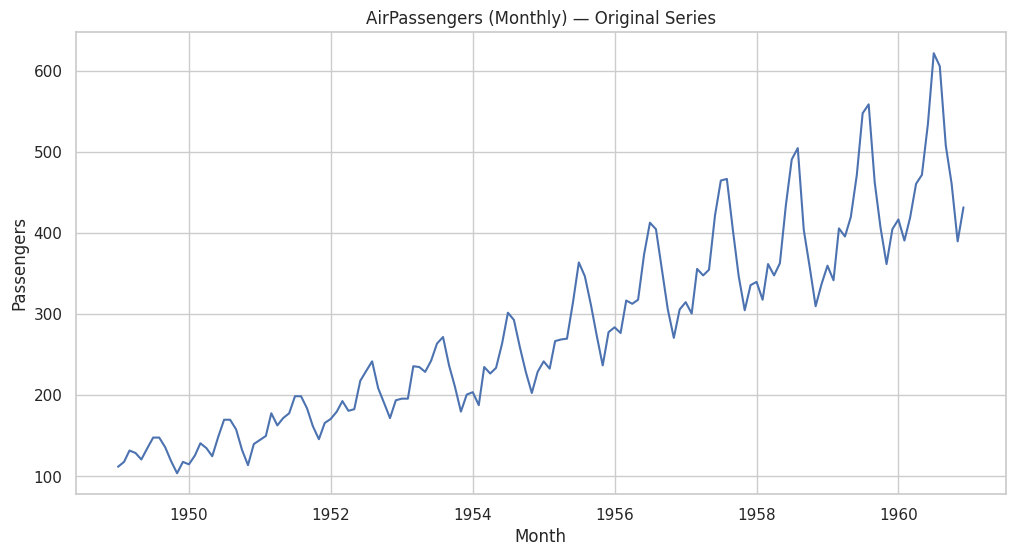

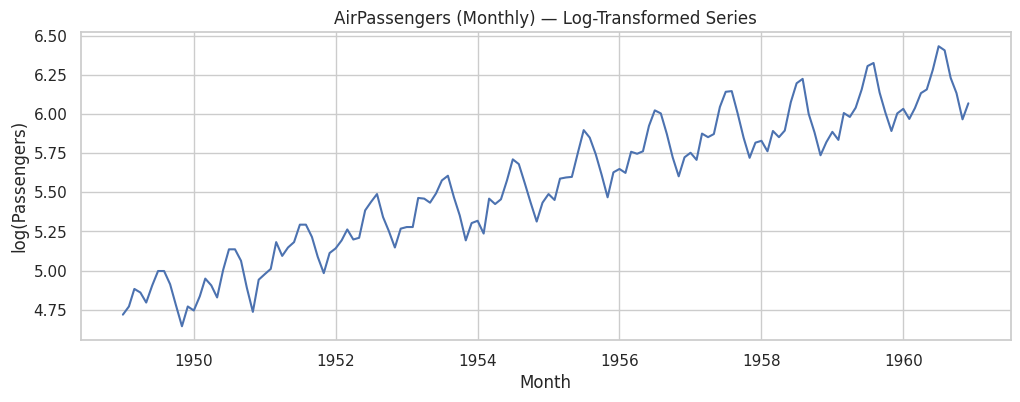

In [2]:
plt.figure(figsize=(12, 6))
plt.plot(df.index, df["Passengers"])
plt.title("AirPassengers (Monthly) — Original Series")
plt.xlabel("Month")
plt.ylabel("Passengers")
plt.show()

print("\n")

plt.figure(figsize=(12, 4))
plt.plot(df.index, df["LogPassengers"])
plt.title("AirPassengers (Monthly) — Log-Transformed Series")
plt.xlabel("Month")
plt.ylabel("log(Passengers)")
plt.show()

- We visualize the patterns and trends of the dataset to identify:
- Trend: if passenger counts increase or decrease over time.
- Seasonality: whether the pattern repeats at regular intervals
- This will help justify seasonal mode, whether SARIMA/SARIMAX

# Create the Forecasting Model

In [3]:
def adf_test(series, name="Series"):
    series = series.dropna()
    stat, pval, _, _, crit, _ = adfuller(series)
    print(f"\nADF Test: {name}")
    print("ADF Statistic:", stat)
    print("p-value:", pval)
    print("Critical Values:", crit)

adf_test(df["LogPassengers"], "LogPassengers")

test_size = 24
train=df.iloc[:-test_size]
test=df.iloc[-test_size:]

y_train=train["LogPassengers"]
y_test=test["LogPassengers"]

order=(1,1,1)
seasonal_order=(1,1,1,12)

model=SARIMAX(
    y_train,
    order=order,
    seasonal_order=seasonal_order,
    enforce_stationarity=False,
    enforce_invertibility=False
)

results=model.fit(disp=False)
print("\nModel Summary: ")
print(results.summary())


ADF Test: LogPassengers
ADF Statistic: -1.7170170891069683
p-value: 0.4223667747703874
Critical Values: {'1%': np.float64(-3.4816817173418295), '5%': np.float64(-2.8840418343195267), '10%': np.float64(-2.578770059171598)}

Model Summary: 
                                     SARIMAX Results                                      
Dep. Variable:                      LogPassengers   No. Observations:                  120
Model:             SARIMAX(1, 1, 1)x(1, 1, 1, 12)   Log Likelihood                 171.311
Date:                            Sun, 08 Feb 2026   AIC                           -332.622
Time:                                    22:28:15   BIC                           -319.959
Sample:                                01-01-1949   HQIC                          -327.509
                                     - 12-01-1958                                         
Covariance Type:                              opg                                         
                 coef    std err

- Check stationarily using ADF test. Learning step similar to typical test scripts.
- Split into train/test data using the last 24 months as test set.
- Fit a Seasonal ARIMA model because AirPassengers is seasonal
- Like the test script, this is the seasonal extention of ARIMA, which is the
- same "ARIMA idea", just with seasonality.

# Model Results


EVALUATION ON TESTSET (Last 24 months)
MAE: 43.73
RMSE: 48.25
MAPE: 0.09%


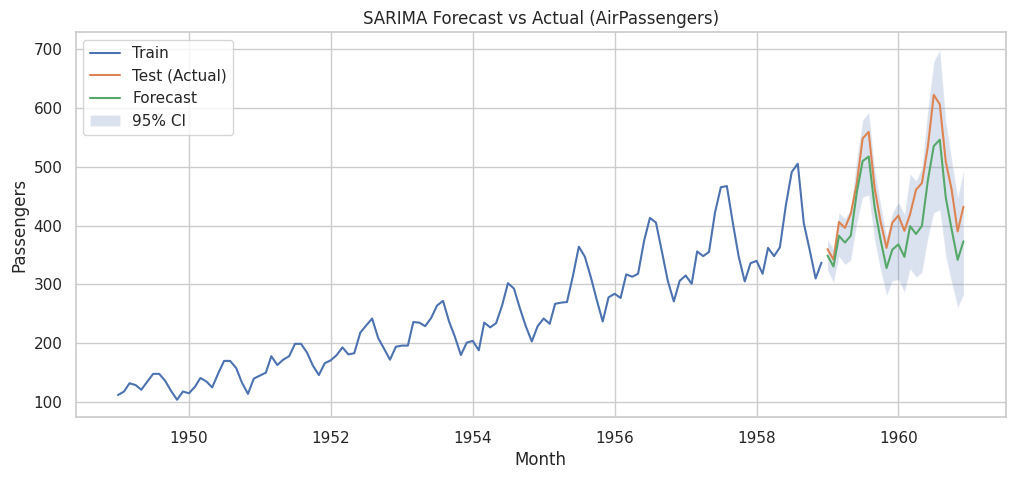

In [4]:
forecast_obj=results.get_forecast(steps=len(test))
pred_log=forecast_obj.predicted_mean
pred_ci_log=forecast_obj.conf_int()
pred=np.exp(pred_log)
ci_lower=np.exp(pred_ci_log.iloc[:,0])
ci_upper=np.exp(pred_ci_log.iloc[:,1])
y_true=test["Passengers"]

from sklearn.metrics import mean_absolute_error

mae=mean_absolute_error(y_true, pred)
rmse=np.sqrt(mean_squared_error(y_true, pred))
mape=mean_absolute_percentage_error(y_true, pred)

print("\nEVALUATION ON TESTSET (Last 24 months)")
print(f"MAE: {mae:.2f}")
print(f"RMSE: {rmse:.2f}")
print(f"MAPE: {mape:.2f}%")

plt.figure(figsize=(12, 5))
plt.plot(train.index, train["Passengers"], label="Train")
plt.plot(test.index, test["Passengers"], label="Test (Actual)")
plt.plot(test.index, pred, label="Forecast")
plt.fill_between(test.index, ci_lower, ci_upper, alpha=0.2, label="95% CI")
plt.title("SARIMA Forecast vs Actual (AirPassengers)")
plt.xlabel("Month")
plt.ylabel("Passengers")
plt.legend()
plt.show()

- Forecast the test period
- Convert forecasts back from log scale to original scale
- evaluate using MAE, RMSE, and MAPE
- Plot Train vs Test vs Forecast + Confidence interna=vls

# Model Discussion

The analysis implemented a Seasonal AutoRegressive Integrated Moving Average  model to forecast monthly air passenger traffic, effectively addressing the dataset's distinct trend and seasonality. To stabilize the variance and handle the non-stationary nature of the raw data, a logarithmic transformation was applied to the "Passengers" variable prior to model fitting. The selected model architecture employed non-seasonal parameters of 1,1,1 and seasonal parameters of 1,1,1,12, allowing it to capture both short-term dependencies and the recurring annual cycles inherent in travel data.

The model's predictive capability was evaluated on a test set comprising the final 24 months of the time series. Post-forecast, the results were inversely transformed from the log scale to compare against the actual passenger counts using standard performance metrics, specifically Mean Absolute Error, Root Mean Squared Error, and Mean Absolute Percentage Error. Visual inspection of the results confirms that the model successfully tracked the upward trend and the amplitude of seasonal fluctuations, with the 95% confidence intervals providing a measure of uncertainty around the forecasted values.

# References
Box, G. E. P., Jenkins, G. M., Reinsel, G. C., & Ljung, G. M. (2015). Time series analysis: Forecasting and control (5th ed.). Wiley.

Hunter, J. D. (2007). Matplotlib: A 2D graphics environment. Computing in Science & Engineering, 9(3), 90–95. https://doi.org/10.1109/MCSE.2007.55

Hyndman, R. J., & Athanasopoulos, G. (2021). Forecasting: Principles and practice (3rd ed.). OTexts. https://otexts.com/fpp3/

McKinney, W. (2010). Data structures for statistical computing in Python. In S. van der Walt & J. Millman (Eds.), Proceedings of the 9th Python in Science Conference (pp. 51–56). https://doi.org/10.25080/Majora-92bf1922-00a

Pedregosa, F., Varoquaux, G., Gramfort, A., Michel, V., Thirion, B., Grisel, O., Blondel, M., Prettenhofer, P., Weiss, R., Dubourg, V., Vanderplas, J., Passos, A., Cournapeau, D., Brucher, M., Perrot, M., & Duchesnay, E. (2011). Scikit-learn: Machine learning in Python. Journal of Machine Learning Research, 12, 2825–2830.

Seabold, S., & Perktold, J. (2010). statsmodels: Econometric and statistical modeling with python. In S. van der Walt & J. Millman (Eds.), Proceedings of the 9th Python in Science Conference (pp. 92–96). https://doi.org/10.25080/Majora-92bf1922-011